# imports

In [1]:
import os
import shutil
from typing import List, Tuple, Optional
from pathlib import Path
from typing import List
import pandas as pd
import lightgbm

def imputer(df, target_columns=None, lgbm_params=None):
    """
    Impute missing values in a time-series Series or DataFrame.
    Here we apply a linearly interpolation on 2 consecutive NaNs or fewer.
    If there is a larger chunk of NaNs then we use a LightGBM regressor to fill in longer missing intervals.

    Parameters
    ----------
    df : pd.Series or pd.DataFrame
        A pandas Series or DataFrame with a DatetimeIndex.
    target_columns : list or None
        Which columns to impute. If None, all columns with NaNs will be imputed.
        (Ignored if df is a Series, because there's only one column.)
    lgbm_params : dict or None
        Parameters for the LGBMRegressor. If None, defaults are used.

    Returns
    -------
    pd.Series or pd.DataFrame
        The same type as `df`, with missing values imputed.
    """
    # Check if input is a Series
    was_series = False
    original_name = None
    if isinstance(df, pd.Series):
        was_series = True
        original_name = df.name if df.name is not None else "value"
        df = df.to_frame(name=original_name)
    
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame/Series must have a DatetimeIndex.")
    
    # Identify columns needing imputation
    if target_columns is None:
        target_columns = [col for col in df.columns if df[col].isna().any()]
    
    # First pass: linearly interpolate small gaps (<= 2 consecutive NaNs)
    for col in target_columns:
        small_gaps = df[col].isna().astype(int).groupby(df[col].notna().cumsum()).sum()
        if any((small_gaps <= 2) & (small_gaps > 0)):
            print(f"Column '{col}' has small gaps (<= 2 consecutive NaNs).")
    df[target_columns] = df[target_columns].interpolate(method='linear', limit=2)
    
    # Default LightGBM parameters if none provided
    if lgbm_params is None:
        lgbm_params = {
            'n_estimators': 500,
            'learning_rate': 0.1,
            'random_state': 42
        }

    # Create time-based features
    global_time_features = pd.DataFrame(index=df.index)
    global_time_features['minute'] = df.index.minute
    global_time_features['hour'] = df.index.hour
    global_time_features['day'] = df.index.day
    global_time_features['dayofweek'] = df.index.dayofweek
    global_time_features['month'] = df.index.month

    #LightGBM for larger gaps
    for target in target_columns:
        # Check if there are still missing values after small-gap interpolation
        if not df[target].isna().any():
            continue 
        print(f"Column '{target}' has large gaps (> 2 consecutive NaNs).")

        # we only train the model on rows for which the target column has non‐missing values
        not_null_mask = df[target].notna()
        y_train = df.loc[not_null_mask, target]

        # Build training features
        other_cols = df.columns.difference([target])
        X_train = pd.concat([df.loc[not_null_mask, other_cols],
                             global_time_features.loc[not_null_mask]], axis=1)

        # Train LightGBM
        model = lightgbm.LGBMRegressor(**lgbm_params,verbose=-1)
        model.fit(X_train, y_train)

        # Predict for the missing rows
        null_mask = df[target].isna()
        if null_mask.any():
            X_missing = pd.concat([df.loc[null_mask, other_cols],
                                   global_time_features.loc[null_mask]], axis=1)
            df.loc[null_mask, target] = model.predict(X_missing)

    if was_series:
        col_name = df.columns[0]
        df_series = df[col_name]
        df_series.name = original_name
        return df_series

    return df

def feature_correlation_sorter_and_remover(df: pd.DataFrame, target: str, threshold: float = 0.1) -> pd.Series:
    """
    This function sorts the features based on their correlation with the target 
    and removes the ones that are below the threshold.
    
    Parameters:
        df (pd.DataFrame): The DataFrame with the features and the target column.
        target (str): The name of the target column.
        threshold (float): The threshold for the correlation (default is 0.1).
    
    Returns:
        pd.Series: The features (rows) that are above the threshold and their correlation with the target.
    """
    # Compute correlation with the target column
    correlation_with_target = df.corr(method="pearson")[target].abs()
    
    # Sort features by correlation values in descending order
    sorted_features = correlation_with_target.sort_values(ascending=False)
    
    # Filter features based on the threshold
    filtered_features = sorted_features[sorted_features >= threshold]

    # Return the filtered and sorted features with their correlations
    return filtered_features.drop(target, errors='ignore')


def list_creator_flagger(
    df: pd.DataFrame, 
    substrings: Optional[List[str]] = None
) -> Tuple[List[str], List[str]]:
    """
    Separates DataFrame columns into two lists: those containing specified substrings 
    and those that do not.

    Parameters:
        df (pd.DataFrame): The DataFrame with the features.
        substrings (List[str], optional): The list of substrings to search for in column names.
            Default is ['flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 'weekend', 
                       'days_in_month', 'hour', 'minute'].

    Returns:
        - non_flag_columns (List[str]): Columns that do not contain the specified substrings.
        - flag_columns (List[str]): Columns that contain the specified substrings.
    """
    if substrings is None:
        substrings = [
            'flag', 'cos', 'sin', 'day_of_week', 'day_of_month', 
            'weekend', 'days_in_month', 'hour', 'minute'
        ]

    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return [], []

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns

def empty_folder(folder: str) -> None:
    """
    Empties a folder by deleting all its contents. If the folder does not exist, it creates it.

    Args:
        folder (str): The path to the folder to be emptied.
    """
    # Get the absolute path of the folder
    absolute_folder_path = os.path.abspath(folder)
    print(f"Attempting to empty folder: {absolute_folder_path}")
    
    # Check if the directory exists; create it if not
    if not os.path.exists(absolute_folder_path):
        os.makedirs(absolute_folder_path)  # Creates the folder if it doesn't exist
        print(f"Folder did not exist and was created: {absolute_folder_path}")
        return  # Exit after creating, no need to empty

    print(f"Folder exists and will be emptied: {absolute_folder_path}")
        
    # Iterate over the items in the directory
    for item in os.listdir(absolute_folder_path):
        item_path = os.path.join(absolute_folder_path, item)
        print(f"Processing item: {item_path}")
        
        # Delete file or directory
        try:
            if os.path.isfile(item_path):
                os.remove(item_path)
                print(f"Deleted file: {item_path}")
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
                print(f"Deleted directory: {item_path}")
        except Exception as e:
            print(f"Error deleting {item_path}: {e}")
    
    print(f"The folder '{folder}' has been emptied.")

def save_best_params_to_csv(study, path: str, hours: int) -> None:
    """
    Save the best parameters from an Optuna study to a CSV file in the 'models' directory.
    Every time the function is called, it appends the new data to the existing CSV file.

    Args:
        study: Optuna study object containing the best parameters and trial results.
        path (str): Base path where the 'models' folder is located.
        hours (int): Multiplication factor for 'hours_in'.
    """
    # Extract best parameters and additional information
    best_params = study.best_params.copy()
    best_params["mse"] = study.best_trial.value
    best_params["trials"] = len(study.trials)
    best_params['hours_in'] *= hours  # Convert back to points

    # Handle `fc_layers` (convert to string for saving)
    fc_layers = [
        best_params.pop(f"fc_layer_{i+1}", None) for i in range(best_params.get("n_layers", 0))
    ]
    best_params["fc_layers"] = ",".join(map(str, fc_layers))  # Save as comma-separated string

    # Define the column names
    columns = [
        'hours_in', 'hours_out', 'suggested_hidden_dim', 'n_rnn_layers',
        'dropout', 'lr','fc_layers', 'mse', 'trials'
    ]

    # Create a DataFrame for the best parameters
    best_params_df = pd.DataFrame([best_params])

    # Define the file path
    target_dir = Path(path) / 'models'
    hyper_params_filepath = target_dir / "hyper_params_df.csv"
    print(f"Saving to file: {hyper_params_filepath}")

    # Check if the file exists
    if hyper_params_filepath.is_file():
        # Read the existing file
        existing_df = pd.read_csv(hyper_params_filepath)
        print("File exists. Appending data.")
        
        if set(columns).issubset(existing_df.columns):
            # Append new data to existing DataFrame
            updated_df = pd.concat([existing_df, best_params_df], ignore_index=True)
        else:
            print("Warning: CSV columns do not match expected columns. Columns will be reset.")
            # Create a new DataFrame with the correct columns
            updated_df = pd.DataFrame(columns=columns)
            updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)
    else:
        print("File does not exist. Creating new file.")
        # Create a new DataFrame with the correct columns
        updated_df = pd.DataFrame(columns=columns)
        updated_df = pd.concat([updated_df, best_params_df], ignore_index=True)

    # Save the DataFrame to CSV
    updated_df.to_csv(hyper_params_filepath, index=False)
    print("Data saved successfully.")
    
def read_hyper_params(path: str) -> dict:
    """
    Reads the hyperparameters from the CSV file and returns the last line as a dictionary.

    Args:
        path (str): The path to the folder where the models are stored.

    Returns:
        dict: The last line of the CSV file as a dictionary.
    
    Raises:
        ValueError: If the CSV file is empty.
    """
    # Define the path to the CSV file
    path_csv = Path(path) / "models" / "hyper_params_df.csv"
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(path_csv)
    
    if df.empty:
        raise ValueError("The CSV file is empty.")
    
    # Get the last row as a Series
    last_line = df.iloc[-1]
    
    # Convert the Series to a dictionary
    last_line_dict = last_line.to_dict()
    
    # Process `fc_layers` (convert back to a list of integers)
    if "fc_layers" in last_line_dict:
        last_line_dict["fc_layers"] = list(map(int, last_line_dict["fc_layers"].split(",")))

    # Define the keys that should not be converted to int
    exclude_from_int_conversion = {"dropout", "lr", "fc_layers"}
    
    # Process the dictionary
    processed_dict = {}
    for key, value in last_line_dict.items():
        if key in exclude_from_int_conversion:
            processed_dict[key] = value
        else:
            try:
                processed_dict[key] = int(value)
            except (ValueError, TypeError):
                processed_dict[key] = value
    
    return processed_dict

def separate_past_and_future_features(ordered_features_list):
    """
    Separates features into past and future covariates based on specific conditions.

    Args:
        ordered_features_list (list of str): List of feature names in the desired order.

    Returns:
        tuple: A tuple containing two lists:
            - past_covariates (list of str): Features considered as past covariates.
            - future_covariates (list of str): Features considered as future covariates.
    """
    past_covariates = []
    future_covariates = []
    
    future_condition_strings = [
        "sin", "cos", "hour", "flag", "day", "month", "week",
        "weekend", "day_of_week", "day_of_month", "days_in_month",
        "minute"
    ]
    
    for feature in ordered_features_list:
        if any(condition_string in feature for condition_string in future_condition_strings):
            future_covariates.append(feature)
        else:
            past_covariates.append(feature)
    
    return past_covariates, future_covariates


# start

In [2]:
import re
import pandas as pd
from pathlib import Path

# ============================================================
# LOAD RAW FILE
# ============================================================
file_path = Path(r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\raw\Denmark\Thyle_data.xlsx")

raw = pd.read_excel(file_path)

meta_device = raw.iloc[0]
meta_measurement = raw.iloc[1]
meta_id = raw.iloc[2]
meta_location = raw.iloc[3]

df = raw.iloc[4:].copy().reset_index(drop=True)
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

for col in df.columns:
    if col != "Time":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep stable occupancy period
df = df[df["Time"] >= "2025-06-01"].copy().reset_index(drop=True)

# ============================================================
# METADATA TABLE
# ============================================================
meta_rows = []
for col in df.columns:
    if col == "Time":
        continue

    meta_rows.append({
        "col": col,
        "device": str(meta_device[col]).strip() if pd.notna(meta_device[col]) else "",
        "measurement": str(meta_measurement[col]).strip() if pd.notna(meta_measurement[col]) else "",
        "meter_id": str(meta_id[col]).strip() if pd.notna(meta_id[col]) else "",
        "location": str(meta_location[col]).strip() if pd.notna(meta_location[col]) else "",
    })

meta = pd.DataFrame(meta_rows)

# ============================================================
# CONVERT ALL COUNTERS TO HOURLY KWH
# ============================================================
df_interval = df.copy()

for _, row in meta.iterrows():
    col = row["col"]
    measurement = row["measurement"].lower().strip()

    # Per email: only 'consumption' is already hourly.
    # Everything else is a cumulative counter.
    if measurement != "consumption":
        s = df_interval[col].diff()
        s[s < 0] = pd.NA   # remove reset/bad jumps
        df_interval[col] = s

# ============================================================
# IDENTIFY HOUSEHOLD LOCATIONS
# ============================================================
def is_household_location(loc: str) -> bool:
    loc = str(loc).strip()
    return bool(re.fullmatch(r"Mulden\s+\d+[A-Z]", loc))

household_locations = sorted(
    [loc for loc in meta["location"].dropna().unique() if is_household_location(loc)]
)

location_to_home = {
    loc: f"home_{i+1}"
    for i, loc in enumerate(household_locations)
}

# ============================================================
# BUILD HOUSEHOLD LOAD = ALL IMPORTING DEVICES AT SAME LOCATION
# INCLUDING Varmepumpe
# ============================================================
household_load = pd.DataFrame({"Time": df_interval["Time"].to_numpy()})

for loc, home_name in location_to_home.items():
    cols_at_location = meta.loc[meta["location"] == loc, "col"].tolist()
    household_load[home_name] = df_interval[cols_at_location].sum(axis=1, skipna=True).to_numpy()

household_load = household_load.sort_values("Time").reset_index(drop=True)

print(household_load.head())

                 Time  home_1  home_2  home_3  home_4  home_5  home_6  home_7  \
0 2025-06-01 00:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1 2025-06-01 01:00:00     0.1     0.0     0.0     0.0     0.0     0.0     0.3   
2 2025-06-01 02:00:00     0.1     1.3     0.0     0.0     0.6     0.3     0.3   
3 2025-06-01 03:00:00     0.0     1.0     0.3     0.3     0.2     0.0     0.3   
4 2025-06-01 04:00:00     0.1     0.1     1.5     0.0     2.3     0.5     0.4   

   home_8  home_9  
0     0.0     0.0  
1     0.7     0.1  
2     2.2     0.0  
3     0.9     0.0  
4     0.8     0.0  


In [3]:
for loc, home_name in location_to_home.items():
    print(f"\n{home_name} -> {loc}")
    print(
        meta.loc[meta["location"] == loc, ["col", "device", "measurement"]]
        .sort_values(["device", "measurement"])
        .to_string(index=False)
    )


home_1 -> Mulden 10A
  col                 device           measurement
92659 Fælles net eksporteret active_import_counter
88433             Varmepumpe active_import_counter

home_2 -> Mulden 11A
  col                 device           measurement
89325 Fælles net eksporteret active_import_counter
89326             Varmepumpe active_import_counter

home_3 -> Mulden 12A
  col                 device           measurement
88940 Fælles net eksporteret active_import_counter
88939             Varmepumpe active_import_counter

home_4 -> Mulden 25A
  col                 device           measurement
89339 Fælles net eksporteret active_import_counter
89340             Varmepumpe active_import_counter

home_5 -> Mulden 26A
  col                 device           measurement
89312 Fælles net eksporteret active_import_counter
89313             Varmepumpe active_import_counter

home_6 -> Mulden 32A
  col                 device           measurement
89318 Fælles net eksporteret active_import_counter
8

In [4]:
heatpump_load = pd.DataFrame({"Time": df_interval["Time"].to_numpy()})

for loc, home_name in location_to_home.items():
    hp_cols = meta.loc[
        (meta["location"] == loc) &
        (meta["device"].str.contains("Varmepumpe", case=False, na=False)),
        "col"
    ].tolist()

    heatpump_load[home_name] = df_interval[hp_cols].sum(axis=1, skipna=True).to_numpy()

print(heatpump_load.head())

                 Time  home_1  home_2  home_3  home_4  home_5  home_6  home_7  \
0 2025-06-01 00:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1 2025-06-01 01:00:00     0.1     0.0     0.0     0.0     0.0     0.0     0.3   
2 2025-06-01 02:00:00     0.1     1.3     0.0     0.0     0.6     0.3     0.3   
3 2025-06-01 03:00:00     0.0     1.0     0.3     0.3     0.2     0.0     0.3   
4 2025-06-01 04:00:00     0.1     0.1     1.5     0.0     2.3     0.5     0.4   

   home_8  home_9  
0     0.0     0.0  
1     0.7     0.1  
2     2.2     0.0  
3     0.9     0.0  
4     0.8     0.0  


In [5]:
# 1) Show which raw columns belong to each home
for loc, home_name in location_to_home.items():
    print(f"\n{home_name} -> {loc}")
    print(
        meta.loc[meta["location"] == loc, ["col", "device", "measurement"]]
        .sort_values(["device", "measurement"])
        .to_string(index=False)
    )


home_1 -> Mulden 10A
  col                 device           measurement
92659 Fælles net eksporteret active_import_counter
88433             Varmepumpe active_import_counter

home_2 -> Mulden 11A
  col                 device           measurement
89325 Fælles net eksporteret active_import_counter
89326             Varmepumpe active_import_counter

home_3 -> Mulden 12A
  col                 device           measurement
88940 Fælles net eksporteret active_import_counter
88939             Varmepumpe active_import_counter

home_4 -> Mulden 25A
  col                 device           measurement
89339 Fælles net eksporteret active_import_counter
89340             Varmepumpe active_import_counter

home_5 -> Mulden 26A
  col                 device           measurement
89312 Fælles net eksporteret active_import_counter
89313             Varmepumpe active_import_counter

home_6 -> Mulden 32A
  col                 device           measurement
89318 Fælles net eksporteret active_import_counter
8

In [6]:
# 2) Build heat-pump-only and non-heat-pump-only series
heatpump_load = pd.DataFrame({"Time": df_interval["Time"].to_numpy()})
other_load = pd.DataFrame({"Time": df_interval["Time"].to_numpy()})

for loc, home_name in location_to_home.items():
    hp_cols = meta.loc[
        (meta["location"] == loc) &
        (meta["device"].str.contains("Varmepumpe", case=False, na=False)),
        "col"
    ].tolist()

    other_cols = meta.loc[
        (meta["location"] == loc) &
        (~meta["device"].str.contains("Varmepumpe", case=False, na=False)),
        "col"
    ].tolist()

    heatpump_load[home_name] = df_interval[hp_cols].sum(axis=1, skipna=True).to_numpy()
    other_load[home_name] = df_interval[other_cols].sum(axis=1, skipna=True).to_numpy()

# 3) Check equality: household_load should equal heatpump + other
check = household_load.copy()

for col in household_load.columns:
    if col == "Time":
        continue
    check[col] = household_load[col] - (heatpump_load[col] + other_load[col])

print(check.drop(columns="Time").abs().max())

home_1    4.000000e-01
home_2    1.818989e-12
home_3    8.000000e-01
home_4    1.200000e+00
home_5    1.200000e+00
home_6    3.000000e-01
home_7    9.000000e-01
home_8    2.000000e-01
home_9    0.000000e+00
dtype: float64


<Axes: >

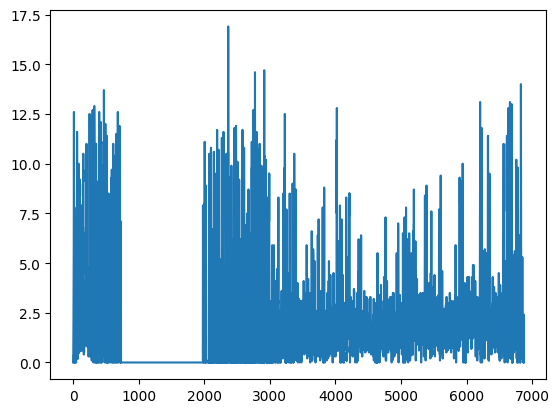

In [7]:
household_load["home_7"].plot()

In [8]:
household_load.isna().sum()

Time      0
home_1    0
home_2    0
home_3    0
home_4    0
home_5    0
home_6    0
home_7    0
home_8    0
home_9    0
dtype: int64

# imputation

In [9]:
import numpy as np
import pandas as pd

# copy so you keep the original safe
household_load_fixed = household_load.copy()

col = "home_7"
min_zero_run = 24  # example: only replace zero runs of at least 24 consecutive hours

s = household_load_fixed[col].copy()
zero_mask = s.eq(0)

# identify consecutive groups
groups = zero_mask.ne(zero_mask.shift()).cumsum()

# length of each consecutive zero/nonzero group
group_sizes = zero_mask.groupby(groups).transform("size")

# mask only long zero runs
long_zero_mask = zero_mask & (group_sizes >= min_zero_run)

# replace with NaN
household_load_fixed.loc[long_zero_mask, col] = np.nan

print(household_load_fixed[[col]].head(50))

    home_7
0      0.0
1      0.3
2      0.3
3      0.3
4      0.4
5      1.7
6      1.7
7      2.2
8      2.9
9      4.0
10     4.5
11     5.9
12     9.7
13    12.3
14    12.6
15     6.0
16     4.5
17     3.1
18     2.4
19     1.5
20     7.8
21     0.1
22     0.0
23     0.0
24     0.1
25     0.0
26     0.3
27     0.3
28     0.3
29     0.3
30     1.1
31     3.7
32     4.8
33     0.0
34     0.0
35     0.0
36     5.4
37     7.1
38     7.2
39     5.0
40     5.3
41     5.6
42     4.9
43     1.7
44     0.4
45     0.1
46     0.1
47     0.0
48     0.2
49     0.3


In [10]:
col = "home_7"
min_zero_run = 24

s = household_load[col]
zero_mask = s.eq(0)
groups = zero_mask.ne(zero_mask.shift()).cumsum()
group_sizes = zero_mask.groupby(groups).transform("size")

long_zero_mask = zero_mask & (group_sizes >= min_zero_run)

zero_runs = (
    household_load.loc[long_zero_mask, ["Time"]]
    .assign(group=groups[long_zero_mask].values)
    .groupby("group")
    .agg(
        start=("Time", "first"),
        end=("Time", "last"),
        length=("Time", "size")
    )
)

print(zero_runs)

                    start                 end  length
group                                                
73    2025-07-01 11:00:00 2025-08-22 11:00:00    1249
83    2025-08-24 11:00:00 2025-08-25 22:00:00      36


In [11]:
import numpy as np
import pandas as pd

household_load_fixed = household_load.copy()
min_zero_run = 24  # change threshold as you like

for col in household_load_fixed.columns:
    if col == "Time":
        continue

    s = household_load_fixed[col].copy()
    zero_mask = s.eq(0)
    groups = zero_mask.ne(zero_mask.shift()).cumsum()
    group_sizes = zero_mask.groupby(groups).transform("size")

    long_zero_mask = zero_mask & (group_sizes >= min_zero_run)
    household_load_fixed.loc[long_zero_mask, col] = np.nan

print(household_load_fixed.isna().sum())

Time         0
home_1       0
home_2       0
home_3       0
home_4       0
home_5       0
home_6       0
home_7    1285
home_8       0
home_9       0
dtype: int64


<Axes: >

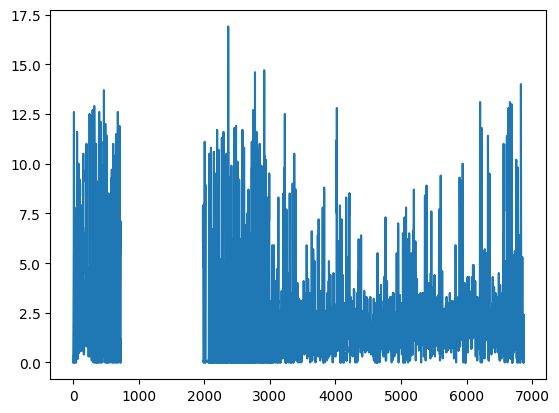

In [12]:
household_load_fixed["home_7"].plot()

In [13]:
household_load = household_load_fixed.copy()
household_load["Time"] = pd.to_datetime(household_load["Time"])
household_load = household_load.set_index("Time")
household_load.index = pd.DatetimeIndex(household_load.index)

print(type(household_load.index))
print(household_load.index)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2025-06-01 00:00:00', '2025-06-01 01:00:00',
               '2025-06-01 02:00:00', '2025-06-01 03:00:00',
               '2025-06-01 04:00:00', '2025-06-01 05:00:00',
               '2025-06-01 06:00:00', '2025-06-01 07:00:00',
               '2025-06-01 08:00:00', '2025-06-01 09:00:00',
               ...
               '2026-03-14 00:00:00', '2026-03-14 01:00:00',
               '2026-03-14 02:00:00', '2026-03-14 03:00:00',
               '2026-03-14 04:00:00', '2026-03-14 05:00:00',
               '2026-03-14 06:00:00', '2026-03-14 07:00:00',
               '2026-03-14 08:00:00', '2026-03-14 09:00:00'],
              dtype='datetime64[ns]', name='Time', length=6875, freq=None)


In [14]:
household_load_imputed = imputer(household_load)

Column 'home_7' has large gaps (> 2 consecutive NaNs).


<Axes: xlabel='Time'>

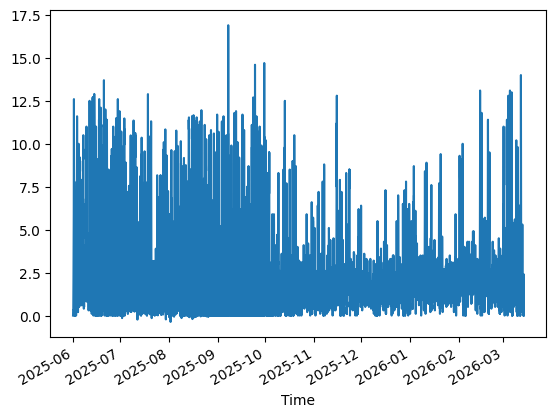

In [15]:
household_load_imputed["home_7"].plot()

In [16]:
household_load_imputed[household_load_imputed < 0] = 0

In [17]:
household_load_imputed

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9
Time,,,,,,,,,
2025-06-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-01 01:00:00,0.1,0.0,0.0,0.0,0.0,0.0,0.3,0.7,0.1
2025-06-01 02:00:00,0.1,1.3,0.0,0.0,0.6,0.3,0.3,2.2,0.0
2025-06-01 03:00:00,0.0,1.0,0.3,0.3,0.2,0.0,0.3,0.9,0.0
2025-06-01 04:00:00,0.1,0.1,1.5,0.0,2.3,0.5,0.4,0.8,0.0
...,...,...,...,...,...,...,...,...,...
2026-03-14 05:00:00,1.0,1.5,0.0,0.7,0.6,1.1,0.5,1.1,0.8
2026-03-14 06:00:00,1.0,1.7,1.4,1.0,0.9,1.1,1.1,1.0,0.0
2026-03-14 07:00:00,0.0,0.0,0.0,1.2,0.0,1.9,2.4,1.0,0.0


# lets add the weather

In [18]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# ============================================================
# 1. USE YOUR IMPUTED HOUSEHOLD DATA
# ============================================================
df_period = household_load_imputed.copy()

# make sure index is DatetimeIndex
df_period.index = pd.to_datetime(df_period.index)

# localize/convert to UTC
if df_period.index.tz is None:
    df_period.index = df_period.index.tz_localize("UTC")
else:
    df_period.index = df_period.index.tz_convert("UTC")

start_ts = df_period.index.min()
end_ts = df_period.index.max()

start_date = start_ts.strftime("%Y-%m-%d")
end_date = end_ts.strftime("%Y-%m-%d")

print("Power period:", start_ts, "→", end_ts)
print("Weather API dates:", start_date, "→", end_date)

# ============================================================
# 2. SETUP OPEN-METEO CLIENT
# ============================================================
cache_session = requests_cache.CachedSession(".cache", expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# ============================================================
# 3. HYLLEGAARD HØJE / MULDEN APPROX COORDINATES
# ============================================================
latitude = 55.5895
longitude = 11.8422

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "precipitation",
        "direct_radiation",
    ],
    "timezone": "UTC",
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

print(f"Coordinates used: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# ============================================================
# 4. PARSE HOURLY WEATHER
# ============================================================
hourly = response.Hourly()

hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
hourly_direct_radiation = hourly.Variables(4).ValuesAsNumpy()

hourly_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left",
)

weather_hourly = pd.DataFrame(
    {
        "temperature_2m": hourly_temperature_2m,
        "relative_humidity_2m": hourly_relative_humidity_2m,
        "wind_speed_10m": hourly_wind_speed_10m,
        "precipitation": hourly_precipitation,
        "direct_radiation": hourly_direct_radiation,
    },
    index=hourly_index,
)

print("\nWeather hourly head:\n", weather_hourly.head())
print("\nWeather hourly tail:\n", weather_hourly.tail())

# ============================================================
# 5. ALIGN WEATHER TO EXACT POWER TIMESTAMPS
# ============================================================
weather_aligned = weather_hourly.reindex(df_period.index)

print("\nWeather aligned shape:", weather_aligned.shape)
print("Power shape:", df_period.shape)

# ============================================================
# 6. JOIN POWER + WEATHER
# ============================================================
df_with_weather = df_period.join(weather_aligned, how="left")

print("\nJoined dataframe head:\n", df_with_weather.head())
print("\nNaNs in weather columns:\n", df_with_weather[[
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation",
    "direct_radiation"
]].isna().sum())

Power period: 2025-06-01 00:00:00+00:00 → 2026-03-14 09:00:00+00:00
Weather API dates: 2025-06-01 → 2026-03-14
Coordinates used: 55.57117462158203°N 11.8421049118042°E
Elevation: 67.0 m asl
Timezone difference to GMT+0: 0s

Weather hourly head:
                            temperature_2m  relative_humidity_2m  \
2025-06-01 00:00:00+00:00           11.40             91.106125   
2025-06-01 01:00:00+00:00           10.95             89.558533   
2025-06-01 02:00:00+00:00           11.45             90.501968   
2025-06-01 03:00:00+00:00           12.65             86.180122   
2025-06-01 04:00:00+00:00           13.10             84.240280   

                           wind_speed_10m  precipitation  direct_radiation  
2025-06-01 00:00:00+00:00        7.434676            0.0               0.0  
2025-06-01 01:00:00+00:00        8.738811            0.0               0.0  
2025-06-01 02:00:00+00:00       11.032987            0.0               0.0  
2025-06-01 03:00:00+00:00       11.983188  

In [19]:
df_with_weather

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
Time,,,,,,,,,,,,,,
2025-06-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.40,91.106125,7.434676,0.0,0.0
2025-06-01 01:00:00+00:00,0.1,0.0,0.0,0.0,0.0,0.0,0.3,0.7,0.1,10.95,89.558533,8.738811,0.0,0.0
2025-06-01 02:00:00+00:00,0.1,1.3,0.0,0.0,0.6,0.3,0.3,2.2,0.0,11.45,90.501968,11.032987,0.0,0.0
2025-06-01 03:00:00+00:00,0.0,1.0,0.3,0.3,0.2,0.0,0.3,0.9,0.0,12.65,86.180122,11.983188,0.0,0.0
2025-06-01 04:00:00+00:00,0.1,0.1,1.5,0.0,2.3,0.5,0.4,0.8,0.0,13.10,84.240280,13.364923,0.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 05:00:00+00:00,1.0,1.5,0.0,0.7,0.6,1.1,0.5,1.1,0.8,3.00,98.943550,3.348193,0.3,0.0
2026-03-14 06:00:00+00:00,1.0,1.7,1.4,1.0,0.9,1.1,1.1,1.0,0.0,3.05,98.943993,2.346913,0.2,0.0
2026-03-14 07:00:00+00:00,0.0,0.0,0.0,1.2,0.0,1.9,2.4,1.0,0.0,3.35,98.249695,1.018234,0.3,0.0


# now we need some data about the prices

DK2 and A44 are the day ahead prices

In [45]:
from nordpool import elspot
import pandas as pd

# ------------------------------------------------------------
# 1. Make sure your power dataframe has a timezone-aware index
# ------------------------------------------------------------
df_period = household_load_imputed.copy()

# If Time is still a column, uncomment:
# df_period["Time"] = pd.to_datetime(df_period["Time"], utc=True)
# df_period = df_period.set_index("Time")

df_period.index = pd.to_datetime(df_period.index, utc=True)

start_ts = df_period.index.min()
end_ts = df_period.index.max()

print("Power period:", start_ts, "->", end_ts)

# ------------------------------------------------------------
# 2. Nord Pool DK2 historical prices, fetched day by day
# ------------------------------------------------------------
prices_spot = elspot.Prices(currency="EUR")

days = pd.date_range(
    start=start_ts.normalize(),
    end=end_ts.normalize(),
    freq="D",
    tz="UTC"
)

price_frames = []

for day in days:
    try:
        data = prices_spot.hourly(end_date=day, areas=["DK2"])
        
        if data is None or "areas" not in data or "DK2" not in data["areas"]:
            print(f"No price data for {day.date()}")
            continue

        values = data["areas"]["DK2"]["values"]
        if not values:
            print(f"Empty DK2 values for {day.date()}")
            continue

        df_day = pd.DataFrame(values)

        # start/end are timezone-aware datetimes from the package
        df_day["Time"] = pd.to_datetime(df_day["start"], utc=True)
        df_day = df_day.set_index("Time")

        df_day = df_day[["value"]].rename(columns={"value": "price_eur_mwh"})
        df_day["price_eur_kwh"] = df_day["price_eur_mwh"] / 1000.0

        price_frames.append(df_day[["price_eur_kwh"]])

    except Exception as e:
        print(f"Failed for {day.date()}: {e}")

# ------------------------------------------------------------
# 3. Combine, deduplicate, sort, trim to your exact range
# ------------------------------------------------------------
df_prices = pd.concat(price_frames).sort_index()
df_prices = df_prices[~df_prices.index.duplicated(keep="first")]

df_prices = df_prices.loc[(df_prices.index >= start_ts) & (df_prices.index <= end_ts)]

print(df_prices.head())
print(df_prices.tail())
print("Price period:", df_prices.index.min(), "->", df_prices.index.max())
print("Number of price rows:", len(df_prices))

# ------------------------------------------------------------
# 4. Join to your household/weather dataframe
# ------------------------------------------------------------
df_final = df_period.join(df_prices[["price_eur_kwh"]], how="left")

print(df_final[["price_eur_kwh"]].head())
print(df_final[["price_eur_kwh"]].isna().sum())

Power period: 2025-06-01 00:00:00+00:00 -> 2026-03-14 09:00:00+00:00
Failed for 2025-06-01: 401 Client Error: Unauthorized for url: https://dataportal-api.nordpoolgroup.com/api/DayAheadPriceIndices?currency=EUR&market=DayAhead&date=2025-06-01&resolutionInMinutes=60&indexNames=DK2
Failed for 2025-06-02: 401 Client Error: Unauthorized for url: https://dataportal-api.nordpoolgroup.com/api/DayAheadPriceIndices?currency=EUR&market=DayAhead&date=2025-06-02&resolutionInMinutes=60&indexNames=DK2
Failed for 2025-06-03: 401 Client Error: Unauthorized for url: https://dataportal-api.nordpoolgroup.com/api/DayAheadPriceIndices?currency=EUR&market=DayAhead&date=2025-06-03&resolutionInMinutes=60&indexNames=DK2
Failed for 2025-06-04: 401 Client Error: Unauthorized for url: https://dataportal-api.nordpoolgroup.com/api/DayAheadPriceIndices?currency=EUR&market=DayAhead&date=2025-06-04&resolutionInMinutes=60&indexNames=DK2
Failed for 2025-06-05: 401 Client Error: Unauthorized for url: https://dataportal-a

KeyboardInterrupt: 

In [46]:
import pandas as pd
import requests
import json

# ------------------------------------------------------------
# 1. Power dataframe with datetime index
# ------------------------------------------------------------
df_period = household_load_imputed.copy()
df_period.index = pd.to_datetime(df_period.index)

# Your index is naive right now; treat it as UTC if that's how you've built everything
if df_period.index.tz is None:
    df_period.index = df_period.index.tz_localize("UTC")
else:
    df_period.index = df_period.index.tz_convert("UTC")

start_ts = df_period.index.min()
end_ts = df_period.index.max()

print("Power period:", start_ts, "->", end_ts)

# ------------------------------------------------------------
# 2. Convert UTC range to Danish local time for Energi Data Service
#    The API interprets start/end in Danish local time.
# ------------------------------------------------------------
start_local = start_ts.tz_convert("Europe/Copenhagen")
end_local = end_ts.tz_convert("Europe/Copenhagen")

# end is exclusive in many APIs, so add a little buffer
end_local_plus = end_local + pd.Timedelta(days=1)

start_str = start_local.strftime("%Y-%m-%dT%H:%M")
end_str = end_local_plus.strftime("%Y-%m-%dT%H:%M")

print("EDS local period:", start_str, "->", end_str)

# ------------------------------------------------------------
# 3. Query Energinet Elspotprices for DK2
# ------------------------------------------------------------
base_url = "https://api.energidataservice.dk/dataset/Elspotprices"

params = {
    "start": start_str,
    "end": end_str,
    "filter": json.dumps({"PriceArea": ["DK2"]}),
    "sort": "HourUTC ASC",
    "limit": 10000,
}

r = requests.get(base_url, params=params, timeout=60)
r.raise_for_status()

data = r.json()

records = data.get("records", [])
print("Number of records fetched:", len(records))

df_prices = pd.DataFrame(records)

print(df_prices.head())
print(df_prices.columns.tolist())

Power period: 2025-06-01 00:00:00+00:00 -> 2026-03-14 09:00:00+00:00
EDS local period: 2025-06-01T02:00 -> 2026-03-15T10:00
Number of records fetched: 2926
               HourUTC               HourDK PriceArea  SpotPriceDKK  \
0  2025-06-01T00:00:00  2025-06-01T02:00:00       DK2    575.297222   
1  2025-06-01T01:00:00  2025-06-01T03:00:00       DK2    552.622462   
2  2025-06-01T02:00:00  2025-06-01T04:00:00       DK2    541.956438   
3  2025-06-01T03:00:00  2025-06-01T05:00:00       DK2    407.175892   
4  2025-06-01T04:00:00  2025-06-01T06:00:00       DK2    260.908824   

   SpotPriceEUR  
0     77.129997  
1     74.089996  
2     72.660004  
3     54.590000  
4     34.980000  
['HourUTC', 'HourDK', 'PriceArea', 'SpotPriceDKK', 'SpotPriceEUR']


In [47]:
# ------------------------------------------------------------
# 4. Parse timestamps and keep the price column
# ------------------------------------------------------------
# Elspotprices usually includes HourUTC and SpotPriceEUR / SpotPriceDKK
df_prices["HourUTC"] = pd.to_datetime(df_prices["HourUTC"], utc=True)
df_prices = df_prices.set_index("HourUTC").sort_index()

# Prefer EUR if present
if "SpotPriceEUR" in df_prices.columns:
    df_prices["price_eur_mwh"] = pd.to_numeric(df_prices["SpotPriceEUR"], errors="coerce")
elif "SpotPriceDKK" in df_prices.columns:
    raise ValueError("Only DKK prices were returned. Ask me and I'll convert them if needed.")
else:
    raise ValueError(f"Could not find expected price column. Columns are: {df_prices.columns.tolist()}")

df_prices["price_eur_kwh"] = df_prices["price_eur_mwh"] / 1000.0

df_prices = df_prices[["price_eur_kwh"]]

# Trim exactly to your power period
df_prices = df_prices.loc[(df_prices.index >= start_ts) & (df_prices.index <= end_ts)]

print(df_prices.head())
print(df_prices.tail())
print("Price period:", df_prices.index.min(), "->", df_prices.index.max())
print("Number of price rows after trim:", len(df_prices))

                           price_eur_kwh
HourUTC                                 
2025-06-01 00:00:00+00:00        0.07713
2025-06-01 01:00:00+00:00        0.07409
2025-06-01 02:00:00+00:00        0.07266
2025-06-01 03:00:00+00:00        0.05459
2025-06-01 04:00:00+00:00        0.03498
                           price_eur_kwh
HourUTC                                 
2025-09-30 17:00:00+00:00        0.35735
2025-09-30 18:00:00+00:00        0.14719
2025-09-30 19:00:00+00:00        0.11601
2025-09-30 20:00:00+00:00        0.10161
2025-09-30 21:00:00+00:00        0.09248
Price period: 2025-06-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00
Number of price rows after trim: 2926


In [59]:
print("df_period:", df_period.index.min(), "->", df_period.index.max(), "len =", len(df_period))
print("df_prices:", df_prices.index.min(), "->", df_prices.index.max(), "len =", len(df_prices))

print(df_period.index[-10:])
print(df_prices.index[-10:])

df_period: 2025-06-01 00:00:00+00:00 -> 2026-03-14 09:00:00+00:00 len = 6875
df_prices: 2025-06-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00 len = 2926
DatetimeIndex(['2026-03-14 00:00:00+00:00', '2026-03-14 01:00:00+00:00',
               '2026-03-14 02:00:00+00:00', '2026-03-14 03:00:00+00:00',
               '2026-03-14 04:00:00+00:00', '2026-03-14 05:00:00+00:00',
               '2026-03-14 06:00:00+00:00', '2026-03-14 07:00:00+00:00',
               '2026-03-14 08:00:00+00:00', '2026-03-14 09:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Time', freq=None)
DatetimeIndex(['2025-09-30 12:00:00+00:00', '2025-09-30 13:00:00+00:00',
               '2025-09-30 14:00:00+00:00', '2025-09-30 15:00:00+00:00',
               '2025-09-30 16:00:00+00:00', '2025-09-30 17:00:00+00:00',
               '2025-09-30 18:00:00+00:00', '2025-09-30 19:00:00+00:00',
               '2025-09-30 20:00:00+00:00', '2025-09-30 21:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name

In [54]:
df_with_weather=df_with_weather.join(df_prices, how="left")

ValueError: columns overlap but no suffix specified: Index(['price_eur_kwh'], dtype='object')

In [58]:
df_with_weather.tail(900)

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation,price_eur_kwh
2026-02-04 22:00:00+00:00,1.8,2.2,2.1,2.0,2.2,1.8,1.3,1.3,0.9,-2.25,82.350456,24.921387,0.0,0.0,NaN
2026-02-04 23:00:00+00:00,1.3,1.9,1.4,1.9,1.9,1.8,0.6,1.3,0.9,-2.15,82.675003,24.592243,0.0,0.0,NaN
2026-02-05 00:00:00+00:00,1.4,1.8,2.9,2.2,1.6,1.9,0.3,1.4,0.9,-2.60,83.558533,23.584808,0.0,0.0,NaN
2026-02-05 01:00:00+00:00,1.3,1.9,2.3,2.3,1.5,1.9,0.6,1.4,1.4,-2.85,85.768105,19.689238,0.0,0.0,NaN
2026-02-05 02:00:00+00:00,1.1,1.9,2.3,2.5,1.4,1.5,3.5,1.6,1.4,-3.35,86.038506,18.519018,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 05:00:00+00:00,1.0,1.5,0.0,0.7,0.6,1.1,0.5,1.1,0.8,3.00,98.943550,3.348193,0.3,0.0,NaN
2026-03-14 06:00:00+00:00,1.0,1.7,1.4,1.0,0.9,1.1,1.1,1.0,0.0,3.05,98.943993,2.346913,0.2,0.0,NaN
2026-03-14 07:00:00+00:00,0.0,0.0,0.0,1.2,0.0,1.9,2.4,1.0,0.0,3.35,98.249695,1.018234,0.3,0.0,NaN
2026-03-14 08:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,3.60,95.853096,3.204809,0.3,0.0,NaN


In [29]:
df_with_weather

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
Time,,,,,,,,,,,,,,
2025-06-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.40,91.106125,7.434676,0.0,0.0
2025-06-01 01:00:00+00:00,0.1,0.0,0.0,0.0,0.0,0.0,0.3,0.7,0.1,10.95,89.558533,8.738811,0.0,0.0
2025-06-01 02:00:00+00:00,0.1,1.3,0.0,0.0,0.6,0.3,0.3,2.2,0.0,11.45,90.501968,11.032987,0.0,0.0
2025-06-01 03:00:00+00:00,0.0,1.0,0.3,0.3,0.2,0.0,0.3,0.9,0.0,12.65,86.180122,11.983188,0.0,0.0
2025-06-01 04:00:00+00:00,0.1,0.1,1.5,0.0,2.3,0.5,0.4,0.8,0.0,13.10,84.240280,13.364923,0.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 05:00:00+00:00,1.0,1.5,0.0,0.7,0.6,1.1,0.5,1.1,0.8,3.00,98.943550,3.348193,0.3,0.0
2026-03-14 06:00:00+00:00,1.0,1.7,1.4,1.0,0.9,1.1,1.1,1.0,0.0,3.05,98.943993,2.346913,0.2,0.0
2026-03-14 07:00:00+00:00,0.0,0.0,0.0,1.2,0.0,1.9,2.4,1.0,0.0,3.35,98.249695,1.018234,0.3,0.0


In [38]:
df_15min = df_with_weather.copy()

if "Time" in df_15min.columns:
    df_15min["Time"] = pd.to_datetime(df_15min["Time"])
    df_15min = df_15min.set_index("Time")

df_15min = df_15min.sort_index()

# remove duplicate timestamps, keep first
df_15min = df_15min[~df_15min.index.duplicated(keep="first")]

# upsample to 15-min and interpolate
df_15min = df_15min.resample("15min").interpolate(method="time")

print(df_15min.head(20))
print(df_15min.tail(20))
print(df_15min.shape)

                           home_1  home_2  home_3  home_4  home_5  home_6  \
Time                                                                        
2025-06-01 00:00:00+00:00   0.000   0.000   0.000   0.000   0.000   0.000   
2025-06-01 00:15:00+00:00   0.025   0.000   0.000   0.000   0.000   0.000   
2025-06-01 00:30:00+00:00   0.050   0.000   0.000   0.000   0.000   0.000   
2025-06-01 00:45:00+00:00   0.075   0.000   0.000   0.000   0.000   0.000   
2025-06-01 01:00:00+00:00   0.100   0.000   0.000   0.000   0.000   0.000   
2025-06-01 01:15:00+00:00   0.100   0.325   0.000   0.000   0.150   0.075   
2025-06-01 01:30:00+00:00   0.100   0.650   0.000   0.000   0.300   0.150   
2025-06-01 01:45:00+00:00   0.100   0.975   0.000   0.000   0.450   0.225   
2025-06-01 02:00:00+00:00   0.100   1.300   0.000   0.000   0.600   0.300   
2025-06-01 02:15:00+00:00   0.075   1.225   0.075   0.075   0.500   0.225   
2025-06-01 02:30:00+00:00   0.050   1.150   0.150   0.150   0.400   0.150   

In [39]:
df_15min

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation
Time,,,,,,,,,,,,,,
2025-06-01 00:00:00+00:00,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,11.400000,91.106125,7.434676,0.0,0.0
2025-06-01 00:15:00+00:00,0.025,0.0,0.0,0.0,0.0,0.000,0.075,0.175,0.025,11.287499,90.719223,7.760709,0.0,0.0
2025-06-01 00:30:00+00:00,0.050,0.0,0.0,0.0,0.0,0.000,0.150,0.350,0.050,11.174999,90.332329,8.086743,0.0,0.0
2025-06-01 00:45:00+00:00,0.075,0.0,0.0,0.0,0.0,0.000,0.225,0.525,0.075,11.062500,89.945435,8.412777,0.0,0.0
2025-06-01 01:00:00+00:00,0.100,0.0,0.0,0.0,0.0,0.000,0.300,0.700,0.100,10.950000,89.558533,8.738811,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 08:00:00+00:00,0.000,0.0,0.0,0.0,0.0,0.500,0.000,0.000,0.000,3.600000,95.853096,3.204809,0.3,0.0
2026-03-14 08:15:00+00:00,0.000,0.0,0.0,0.0,0.0,0.375,0.000,0.000,0.000,3.625000,95.517166,3.692210,0.3,0.0
2026-03-14 08:30:00+00:00,0.000,0.0,0.0,0.0,0.0,0.250,0.000,0.000,0.000,3.650000,95.181229,4.179612,0.3,0.0


# from energynet

In [40]:
import pandas as pd
import requests
import json
from io import StringIO

# ============================================================
# 1. BASE DATAFRAME: YOUR 15-MIN TABLE
# ============================================================
df_base = df_15min.copy()

if "Time" in df_base.columns:
    df_base["Time"] = pd.to_datetime(df_base["Time"], utc=True)
    df_base = df_base.set_index("Time")
else:
    df_base.index = pd.to_datetime(df_base.index, utc=True)

df_base = df_base.sort_index()

start_ts = df_base.index.min()
end_ts = df_base.index.max()

print("df_base:", start_ts, "->", end_ts, "len =", len(df_base))

# ============================================================
# 2. FETCH OLD ENERGINET DATASET (HOURLY)
#    Valid until 2025-09-30
# ============================================================
def fetch_elspotprices(start_ts, end_ts, price_area="DK2"):
    url = "https://api.energidataservice.dk/dataset/Elspotprices"
    params = {
        "start": start_ts.strftime("%Y-%m-%dT%H:%M"),
        "end": end_ts.strftime("%Y-%m-%dT%H:%M"),
        "timezone": "UTC",
        "filter": json.dumps({"PriceArea": [price_area]}),
        "sort": "HourUTC ASC",
        "limit": 0,
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()

    records = r.json().get("records", [])
    if not records:
        return pd.DataFrame(columns=["price_eur_kwh"])

    df = pd.DataFrame(records)
    df["HourUTC"] = pd.to_datetime(df["HourUTC"], utc=True)
    df = df.set_index("HourUTC").sort_index()

    df["SpotPriceEUR"] = pd.to_numeric(df["SpotPriceEUR"], errors="coerce")
    df["price_eur_kwh"] = df["SpotPriceEUR"] / 1000.0

    return df[["price_eur_kwh"]]

# ============================================================
# 3. FETCH NEW ENERGINET DATASET (15-MIN)
#    From 2025-10-01 onward
# ============================================================
def fetch_dayaheadprices_download(start_ts, end_ts, price_area="DK2"):
    url = "https://api.energidataservice.dk/dataset/DayAheadPrices/download"
    params = {
        "format": "csv",
        "start": start_ts.strftime("%Y-%m-%dT%H:%M"),
        "end": end_ts.strftime("%Y-%m-%dT%H:%M"),
        "timezone": "UTC",
        "filter": json.dumps({"PriceArea": [price_area]}),
        "sort": "TimeUTC ASC",
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()

    # IMPORTANT: semicolon separator and decimal comma
    df = pd.read_csv(StringIO(r.text), sep=";", decimal=",")

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace("\ufeff", "", regex=False)
    )

    df["TimeUTC"] = pd.to_datetime(df["TimeUTC"], utc=True)
    df = df.set_index("TimeUTC").sort_index()

    df["DayAheadPriceEUR"] = pd.to_numeric(df["DayAheadPriceEUR"], errors="coerce")
    df["price_eur_kwh"] = df["DayAheadPriceEUR"] / 1000.0

    return df[["price_eur_kwh"]]

# ============================================================
# 4. SPLIT FETCH ACROSS DATASET CHANGE
# ============================================================
cutoff = pd.Timestamp("2025-10-01 00:00:00", tz="UTC")
parts = []

# old hourly data
if start_ts < cutoff:
    old_end = min(end_ts + pd.Timedelta(minutes=15), cutoff)
    df_old = fetch_elspotprices(start_ts, old_end, "DK2")

    # expand hourly prices to 15-min by carrying each hourly price across the hour
    df_old_15 = df_old.resample("15min").ffill()

    parts.append(df_old_15)

# new 15-min data
if end_ts >= cutoff:
    new_start = max(start_ts, cutoff)
    df_new = fetch_dayaheadprices_download(
        new_start,
        end_ts + pd.Timedelta(minutes=15),
        "DK2"
    )
    parts.append(df_new)

# ============================================================
# 5. COMBINE, ALIGN EXACTLY TO df_15min INDEX
# ============================================================
df_prices = pd.concat(parts).sort_index()
df_prices = df_prices[~df_prices.index.duplicated(keep="first")]
df_prices = df_prices.reindex(df_base.index)

print("df_prices:", df_prices.index.min(), "->", df_prices.index.max(), "len =", len(df_prices))
print(df_prices.head())
print(df_prices.tail())
print("Price NaNs:", df_prices["price_eur_kwh"].isna().sum())

# ============================================================
# 6. JOIN WITH YOUR 15-MIN TABLE
# ============================================================
df_15min_final = df_base.join(df_prices, how="left")

print(df_15min_final[["price_eur_kwh"]].head(12))
print(df_15min_final[["price_eur_kwh"]].tail(12))
print(df_15min_final[["price_eur_kwh"]].isna().sum())

df_base: 2025-06-01 00:00:00+00:00 -> 2026-03-14 09:00:00+00:00 len = 27493
df_prices: 2025-06-01 00:00:00+00:00 -> 2026-03-14 09:00:00+00:00 len = 27493
                           price_eur_kwh
Time                                    
2025-06-01 00:00:00+00:00        0.07713
2025-06-01 00:15:00+00:00        0.07713
2025-06-01 00:30:00+00:00        0.07713
2025-06-01 00:45:00+00:00        0.07713
2025-06-01 01:00:00+00:00        0.07409
                           price_eur_kwh
Time                                    
2026-03-14 08:00:00+00:00        0.11998
2026-03-14 08:15:00+00:00        0.11996
2026-03-14 08:30:00+00:00        0.11644
2026-03-14 08:45:00+00:00        0.10795
2026-03-14 09:00:00+00:00        0.11220
Price NaNs: 11
                           price_eur_kwh
Time                                    
2025-06-01 00:00:00+00:00        0.07713
2025-06-01 00:15:00+00:00        0.07713
2025-06-01 00:30:00+00:00        0.07713
2025-06-01 00:45:00+00:00        0.07713
2025-06-01 

In [43]:
df_15min_final

,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation,price_eur_kwh
Time,,,,,,,,,,,,,,,
2025-06-01 00:00:00+00:00,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,11.400000,91.106125,7.434676,0.0,0.0,0.07713
2025-06-01 00:15:00+00:00,0.025,0.0,0.0,0.0,0.0,0.000,0.075,0.175,0.025,11.287499,90.719223,7.760709,0.0,0.0,0.07713
2025-06-01 00:30:00+00:00,0.050,0.0,0.0,0.0,0.0,0.000,0.150,0.350,0.050,11.174999,90.332329,8.086743,0.0,0.0,0.07713
2025-06-01 00:45:00+00:00,0.075,0.0,0.0,0.0,0.0,0.000,0.225,0.525,0.075,11.062500,89.945435,8.412777,0.0,0.0,0.07713
2025-06-01 01:00:00+00:00,0.100,0.0,0.0,0.0,0.0,0.000,0.300,0.700,0.100,10.950000,89.558533,8.738811,0.0,0.0,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 08:00:00+00:00,0.000,0.0,0.0,0.0,0.0,0.500,0.000,0.000,0.000,3.600000,95.853096,3.204809,0.3,0.0,0.11998
2026-03-14 08:15:00+00:00,0.000,0.0,0.0,0.0,0.0,0.375,0.000,0.000,0.000,3.625000,95.517166,3.692210,0.3,0.0,0.11996
2026-03-14 08:30:00+00:00,0.000,0.0,0.0,0.0,0.0,0.250,0.000,0.000,0.000,3.650000,95.181229,4.179612,0.3,0.0,0.11644


# save 

In [44]:
from pathlib import Path

save_path = Path(r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Denmark.csv")

# save with Time as a normal column
df_15min_final_to_save = df_15min_final.reset_index()

df_15min_final_to_save.to_csv(save_path, index=False)

print(f"Saved file to: {save_path}")
print(df_15min_final_to_save.head())
print(df_15min_final_to_save.shape)

Saved file to: C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Denmark.csv
                       Time  home_1  home_2  home_3  home_4  home_5  home_6  \
0 2025-06-01 00:00:00+00:00   0.000     0.0     0.0     0.0     0.0     0.0   
1 2025-06-01 00:15:00+00:00   0.025     0.0     0.0     0.0     0.0     0.0   
2 2025-06-01 00:30:00+00:00   0.050     0.0     0.0     0.0     0.0     0.0   
3 2025-06-01 00:45:00+00:00   0.075     0.0     0.0     0.0     0.0     0.0   
4 2025-06-01 01:00:00+00:00   0.100     0.0     0.0     0.0     0.0     0.0   

   home_7  home_8  home_9  temperature_2m  relative_humidity_2m  \
0   0.000   0.000   0.000       11.400000             91.106125   
1   0.075   0.175   0.025       11.287499             90.719223   
2   0.150   0.350   0.050       11.174999             90.332329   
3   0.225   0.525   0.075       11.062500             89.945435   
4   0.300   0.700   0.100       10.950000             89.5585

In [22]:
import pandas as pd
from pathlib import Path

save_path = Path(r"C:\Users\CR58XM\Documents\GitHub\AAU_learning_to_predict_together_or_alone\DataCleaning\clean\dataset_Denmark.csv")

# read dataset
df_denmark = pd.read_csv(save_path, parse_dates=["timestamp"])


print(df_denmark.head())
print(df_denmark.tail())
print(df_denmark.shape)


            timestamp  home_1  home_2  home_3  home_4  home_5  home_6  home_7  \
0 2025-06-01 00:00:00   0.000     0.0     0.0     0.0     0.0     0.0   0.000   
1 2025-06-01 00:15:00   0.025     0.0     0.0     0.0     0.0     0.0   0.075   
2 2025-06-01 00:30:00   0.050     0.0     0.0     0.0     0.0     0.0   0.150   
3 2025-06-01 00:45:00   0.075     0.0     0.0     0.0     0.0     0.0   0.225   
4 2025-06-01 01:00:00   0.100     0.0     0.0     0.0     0.0     0.0   0.300   

   home_8  home_9  temperature_2m  relative_humidity_2m  wind_speed_10m  \
0   0.000   0.000       11.400000             91.106125        7.434676   
1   0.175   0.025       11.287499             90.719220        7.760709   
2   0.350   0.050       11.174999             90.332330        8.086743   
3   0.525   0.075       11.062500             89.945435        8.412777   
4   0.700   0.100       10.950000             89.558530        8.738811   

   precipitation  direct_radiation  price_eur_kwh  
0         

In [23]:
df_denmark

,timestamp,home_1,home_2,home_3,home_4,home_5,home_6,home_7,home_8,home_9,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,direct_radiation,price_eur_kwh
0,2025-06-01 00:00:00,0.000,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.000,11.400000,91.106125,7.434676,0.0,0.0,0.07713
1,2025-06-01 00:15:00,0.025,0.0,0.0,0.0,0.0,0.000,0.075,0.175,0.025,11.287499,90.719220,7.760709,0.0,0.0,0.07713
2,2025-06-01 00:30:00,0.050,0.0,0.0,0.0,0.0,0.000,0.150,0.350,0.050,11.174999,90.332330,8.086743,0.0,0.0,0.07713
3,2025-06-01 00:45:00,0.075,0.0,0.0,0.0,0.0,0.000,0.225,0.525,0.075,11.062500,89.945435,8.412777,0.0,0.0,0.07713
4,2025-06-01 01:00:00,0.100,0.0,0.0,0.0,0.0,0.000,0.300,0.700,0.100,10.950000,89.558530,8.738811,0.0,0.0,0.07409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27488,2026-03-14 08:00:00,0.000,0.0,0.0,0.0,0.0,0.500,0.000,0.000,0.000,3.600000,95.853096,3.204809,0.3,0.0,0.11998
27489,2026-03-14 08:15:00,0.000,0.0,0.0,0.0,0.0,0.375,0.000,0.000,0.000,3.625000,95.517166,3.692210,0.3,0.0,0.11996
27490,2026-03-14 08:30:00,0.000,0.0,0.0,0.0,0.0,0.250,0.000,0.000,0.000,3.650000,95.181230,4.179612,0.3,0.0,0.11644
27491,2026-03-14 08:45:00,0.000,0.0,0.0,0.0,0.0,0.125,0.000,0.000,0.000,3.675000,94.845290,4.667014,0.3,0.0,0.10795


# find 5 days

In [24]:
import pandas as pd
import numpy as np

# make sure timestamp is datetime
df_denmark = df_denmark.copy()
df_denmark["timestamp"] = pd.to_datetime(df_denmark["timestamp"])
df_denmark = df_denmark.sort_values("timestamp").reset_index(drop=True)

# ------------------------------------------------------------
# 1. Ignore the first 10000 timestamps
# ------------------------------------------------------------
df_after = df_denmark.iloc[10000:].copy()

print("Remaining period:")
print(df_after["timestamp"].min(), "->", df_after["timestamp"].max())
print("Remaining rows:", len(df_after))

# ------------------------------------------------------------
# 2. Find candidate day starts at 00:00:00
#    and keep only full 1-day windows (96 rows for 15-min data)
# ------------------------------------------------------------
candidate_starts = df_after[df_after["timestamp"].dt.time == pd.Timestamp("00:00:00").time()].copy()

valid_starts = []

for ts in candidate_starts["timestamp"]:
    day_slice = df_after[
        (df_after["timestamp"] >= ts) &
        (df_after["timestamp"] < ts + pd.Timedelta(days=1))
    ]
    
    # 96 rows = full 15-min day
    if len(day_slice) == 96:
        valid_starts.append(ts)

valid_starts = sorted(valid_starts)

print("Number of valid full-day starts:", len(valid_starts))
print("First few valid starts:", valid_starts[:10])

# ------------------------------------------------------------
# 3. Randomly select 5 forecast days
# ------------------------------------------------------------
rng = np.random.default_rng(42)   # fixed seed for reproducibility
selected_days = sorted(rng.choice(valid_starts, size=5, replace=False))

print("\nSelected forecast day starts:")
for d in selected_days:
    print(d)

# ------------------------------------------------------------
# 4. Optional: build a dictionary with the 5 selected day slices
# ------------------------------------------------------------
forecast_days = {
    f"day{i+1}": df_denmark[
        (df_denmark["timestamp"] >= ts) &
        (df_denmark["timestamp"] < ts + pd.Timedelta(days=1))
    ].reset_index(drop=True)
    for i, ts in enumerate(selected_days)
}

# example
print("\nExample selected day:")
print(forecast_days["day1"].head())
print(forecast_days["day1"].tail())
print("Rows in day1:", len(forecast_days["day1"]))

Remaining period:
2025-09-13 04:00:00 -> 2026-03-14 09:00:00
Remaining rows: 17493
Number of valid full-day starts: 181
First few valid starts: [Timestamp('2025-09-14 00:00:00'), Timestamp('2025-09-15 00:00:00'), Timestamp('2025-09-16 00:00:00'), Timestamp('2025-09-17 00:00:00'), Timestamp('2025-09-18 00:00:00'), Timestamp('2025-09-19 00:00:00'), Timestamp('2025-09-20 00:00:00'), Timestamp('2025-09-21 00:00:00'), Timestamp('2025-09-22 00:00:00'), Timestamp('2025-09-23 00:00:00')]

Selected forecast day starts:
2025-09-29 00:00:00
2025-12-01 00:00:00
2026-01-09 00:00:00
2026-01-29 00:00:00
2026-03-13 00:00:00

Example selected day:
            timestamp  home_1  home_2  home_3  home_4  home_5  home_6  home_7  \
0 2025-09-29 00:00:00   0.000   0.000     0.0     0.0     0.2     0.0     0.0   
1 2025-09-29 00:15:00   0.025   0.025     0.0     0.0     0.2     0.0     0.0   
2 2025-09-29 00:30:00   0.050   0.050     0.0     0.0     0.2     0.0     0.0   
3 2025-09-29 00:45:00   0.075   0.075